In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import random

In [2]:


def inspect_sample(npz_path):
    print(f"--- Inspecting: {os.path.basename(npz_path)} ---")
    
    # 1. Загрузка данных
    data = np.load(npz_path)
    x = data['x']  # (5, 32, 128, 128) -> [SDF, Trees, Source, WindX, WindY]
    y = data['y']  # (1, 128, 128)     -> [Concentration @ 3m]
    
    # Распаковка каналов
    sdf_3d = x[0]
    lad_3d = x[1]
    source_3d = x[2]
    wind_x_val = x[3, 0, 0, 0] # Константа
    wind_y_val = x[4, 0, 0, 0] # Константа
    
    target_conc = y[0] # 2D слой
    
    # 2. Подготовка срезов для отображения (берем слой Z=1, соотв. ~3м)
    z_slice_idx = 1 
    
    sdf_slice = sdf_3d[z_slice_idx]
    lad_slice = lad_3d[z_slice_idx]
    
    # Для источника берем проекцию (сумма по Z), чтобы видеть где он (даже если он на крыше)
    source_proj = np.max(source_3d, axis=0) 
    
    # 3. Санити-чеки (текстовые)
    print(f"Wind Vector: dPdx={wind_x_val:.2e}, dPdy={wind_y_val:.2e}")
    
    source_coords = np.argwhere(source_3d > 0)
    if len(source_coords) > 0:
        z_min, z_max = source_coords[:,0].min(), source_coords[:,0].max()
        print(f"Source found at Z-levels: {z_min} to {z_max} (Total voxels: {len(source_coords)})")
    else:
        print("WARNING: Source mask is empty! (Parsing error?)")
        
    print(f"Concentration Max: {target_conc.max():.2f}")
    
    # 4. Визуализация
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # --- PLOT 1: Physics Check (Концентрация + Здания + Источник + Ветер) ---
    ax = axes[0]
    # Фон - концентрация
    im = ax.imshow(target_conc, cmap='turbo', origin='lower')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Concentration @ 3m')
    
    # Контуры зданий (SDF = 0 это границы)
    # SDF нормирован, так что ищем малые значения
    ax.contour(sdf_slice, levels=[0.01], colors='black', linewidths=1.5, linestyles='solid', label='Buildings')
    
    # Источник (проекция)
    # Используем mask array, чтобы не закрашивать весь фон
    source_masked = np.ma.masked_where(source_proj == 0, source_proj)
    ax.imshow(source_masked, cmap='Reds', origin='lower', alpha=0.8, vmin=0, vmax=1)
    # Обведем источник белым контуром для видимости
    ax.contour(source_proj, levels=[0.5], colors='white', linewidths=1)
    
    # Стрелка ветра
    # Рисуем в центре карты
    center = 64
    # Нормируем вектор для отрисовки
    w_norm = np.sqrt(wind_x_val**2 + wind_y_val**2)
    if w_norm > 0:
        scale = 20
        ax.arrow(center, center, 
                 (wind_x_val/w_norm)*scale, (wind_y_val/w_norm)*scale, 
                 head_width=5, color='white', linewidth=2)
        ax.text(center, center, "Wind", color='white', fontweight='bold')
    
    ax.set_title(f"Target Conc + Source (Red) + Wind")
    
    # --- PLOT 2: Vegetation Check (Деревья + Здания) ---
    ax = axes[1]
    im2 = ax.imshow(lad_slice, cmap='Greens', origin='lower', vmin=0)
    plt.colorbar(im2, ax=ax, fraction=0.046, pad=0.04, label='LAD (Leaf Density)')
    ax.contour(sdf_slice, levels=[0.01], colors='gray', linewidths=1)
    ax.set_title("Vegetation (LAD) @ 3m")
    
    # --- PLOT 3: Vertical Slice (Боковой разрез через источник) ---
    ax = axes[2]
    # Найдем Y-координату центра источника
    if len(source_coords) > 0:
        y_center = int(np.mean(source_coords[:, 1]))
        x_center = int(np.mean(source_coords[:, 2]))
    else:
        y_center = 64
        x_center = 64
        
    # Разрез XZ (вид сбоку)
    # Берем данные из 4D тензора, который в 'x' лежит (но там нет концентрации в X, 
    # концентрацию надо бы взять из 3D файла, но мы уже сохранили только срез).
    # УПС: Мы в process_experiment сохранили в Y только срез.
    # Для проверки нам придется смотреть только на входные маски в разрезе.
    
    # Рисуем SDF (здания) и Источник в вертикальном разрезе
    sdf_xz = sdf_3d[:, y_center, :] # (32, 128)
    source_xz = source_3d[:, y_center, :]
    
    ax.imshow(sdf_xz, cmap='binary', origin='lower', label='SDF')
    source_masked_xz = np.ma.masked_where(source_xz == 0, source_xz)
    ax.imshow(source_masked_xz, cmap='Reds', origin='lower', alpha=1.0)
    
    ax.set_title(f"Vertical Cut (XZ) at Y={y_center}\nCheck Source Height (Red)")
    ax.set_xlabel("X coordinate")
    ax.set_ylabel("Z layer (0-31)")
    
    plt.tight_layout()
    plt.show()


--- Inspecting: build_cuda1222_scale__output_2026_1_11_17_51_11__tracer8.npz ---
Wind Vector: dPdx=1.49e-04, dPdy=2.03e-04
Source found at Z-levels: 0 to 3 (Total voxels: 6016)
Concentration Max: 35627.46


/tmp/ipykernel_10449/2103557620.py:50: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(sdf_slice, levels=[0.01], colors='black', linewidths=1.5, linestyles='solid', label='Buildings')


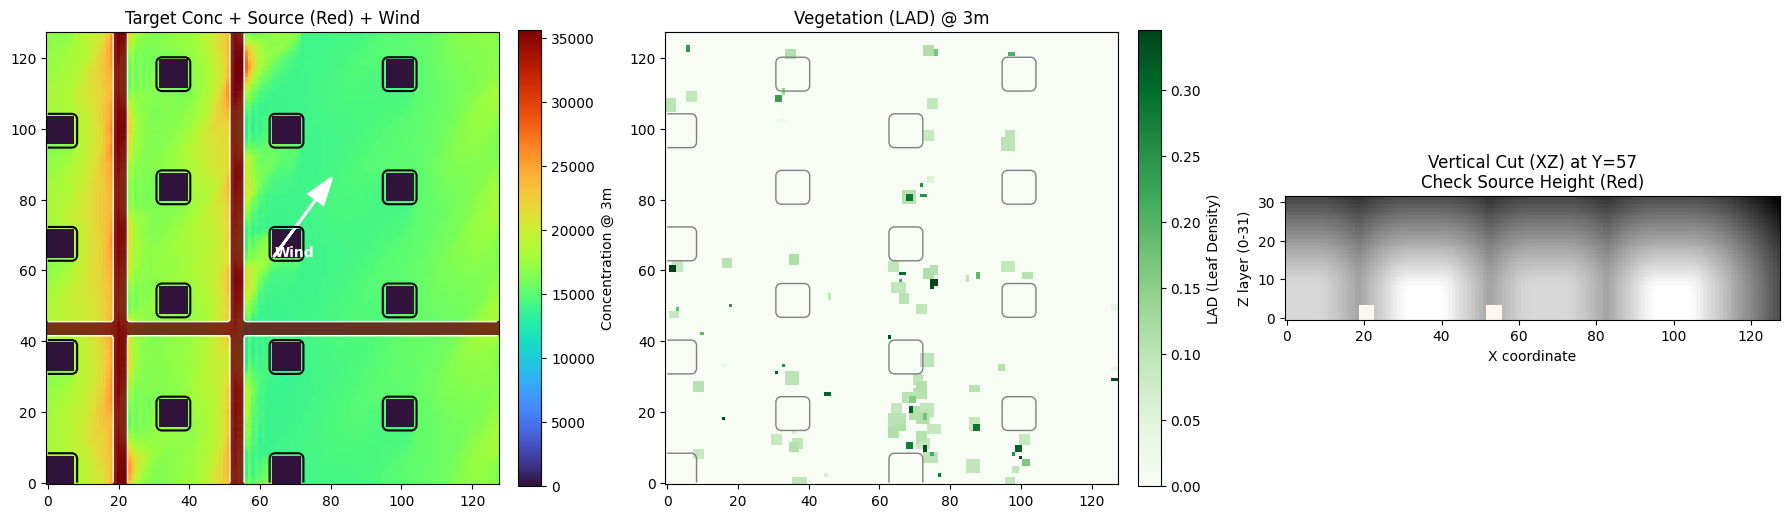

--- Inspecting: build_cuda1222_scale__output_2026_1_11_14_14_18__tracer4.npz ---
Wind Vector: dPdx=2.07e-04, dPdy=1.43e-04
Source found at Z-levels: 0 to 3 (Total voxels: 1056)
Concentration Max: 4062.51


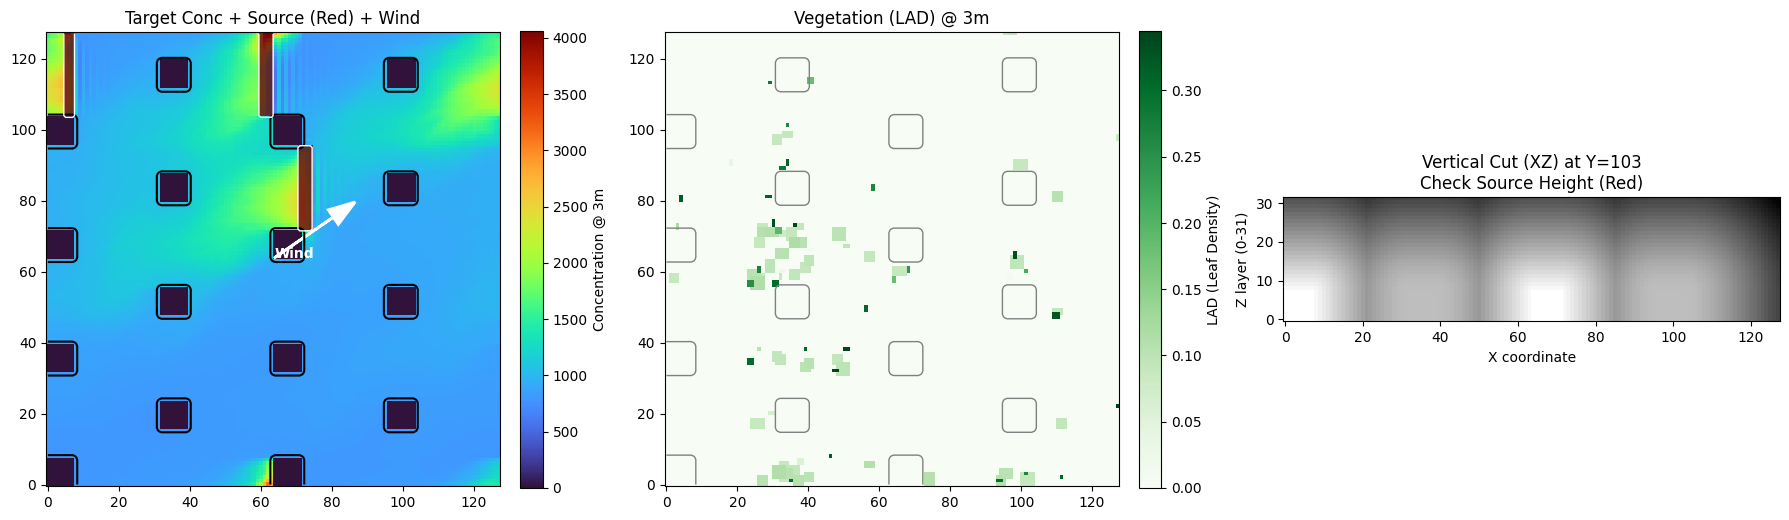

--- Inspecting: build_cuda1222_scale__output_2026_1_11_16_34_17__tracer29.npz ---
Wind Vector: dPdx=2.32e-04, dPdy=-9.40e-05
Source found at Z-levels: 0 to 3 (Total voxels: 4256)
Concentration Max: 2069.62


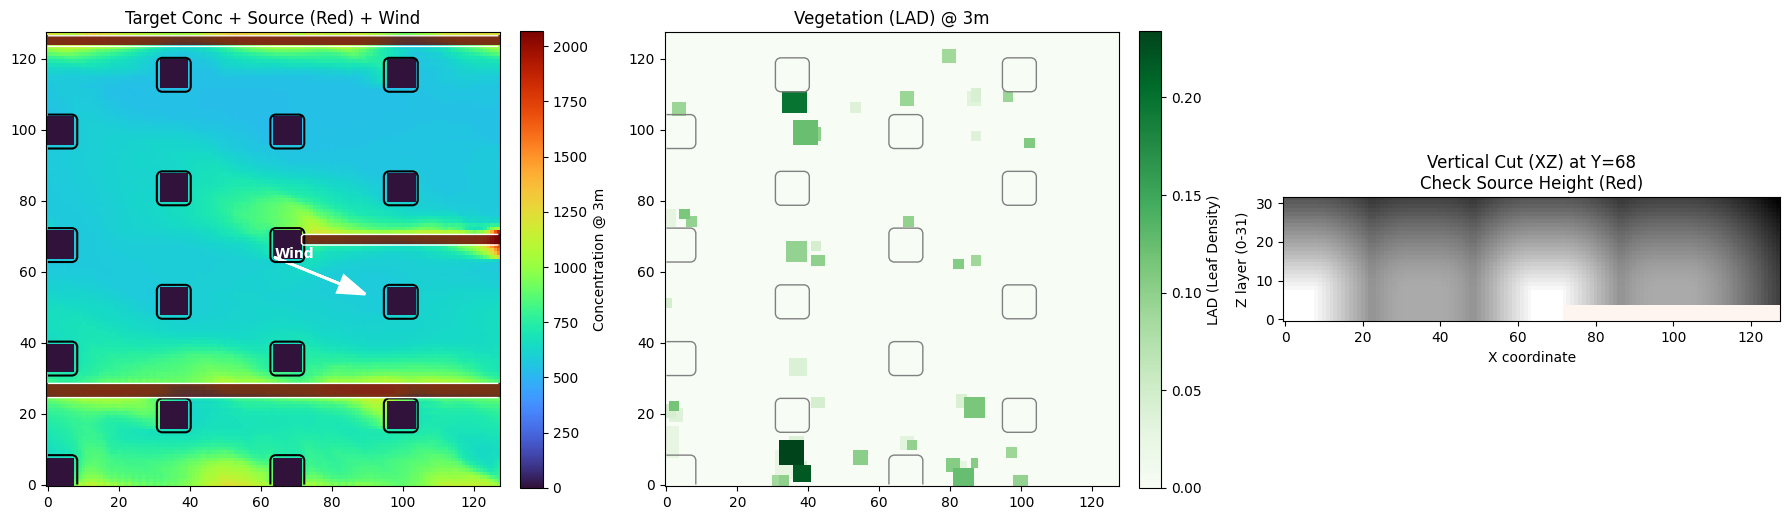

In [3]:
dataset_dir = '/app/urban-layer-dataset/'
files = glob.glob(os.path.join(dataset_dir, '*.npz'))

if not files:
    print("No files found!")
    
# Берем 3 случайных файла
samples = random.sample(files, min(3, len(files)))

for f in samples:
    inspect_sample(f)